We want to be able to compare delay times and formation efficiencies across the boesky suite

In [18]:
import numpy as np
from shared import show_vlines
import h5py
from population_vis import get_formation_efficiency
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm

In [6]:
def get_info(filepath, TYPES):
    # fname = 'Boesky_alpha0.1beta0.5.h5'
    # filepath = f'/Volumes/Elements/{fname}'

    # SET UP DATA -- from a basic dict, port to an h5 file and then store this into the output file
    # now we want to use some real data
    fdata = h5py.File(filepath)
    all_dco_seeds = fdata['BSE_Double_Compact_Objects']['SEED'][()]
    all_seeds = fdata['BSE_System_Parameters']['SEED'][()]
    metallicities = fdata["BSE_System_Parameters"]["Metallicity@ZAMS(1)"][()]
    # potentially mask with/without a stable mass transfer or without an envelope
    mixture_weight = fdata["BSE_System_Parameters"]["mixture_weight"][()]
    fdata.close()
    # TYPES = 'BHNS'
    fe_binned, fe_bins, compasdata = get_formation_efficiency(filepath, types=TYPES)
    delayTimes = compasdata.delayTimes

    # need to get the metallicities as well
    dco_query = np.isin(all_seeds, all_dco_seeds[compasdata.DCOmask])
    dco_metallicities = metallicities[dco_query]
    dco_mixture_weight = mixture_weight[dco_query]
    assert len(delayTimes[()]) == len(dco_metallicities), "Something went wrong with masking for dco metallicities"
    return delayTimes, fe_bins, fe_binned

Loading datasets:   0%|          | 0/4 [00:00<?, ?it/s]

1 binary in COMPAS represents 79.11015055714887  solar masses formed
20000000
1582203011.1429775  [Msun]
ClassCOMPAS: Remember to self.setCOMPASDCOmask()
                    then self.setCOMPASData()
          and optionally self.setGridAndMassEvolved() if using a metallicity grid


/Users/alexandermigala/Documents/Github/metallicity_mergers/population_vis.py:179: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  eff_ax.legend()
/Users/alexandermigala/Documents/Github/metallicity_mergers/population_vis.py:180: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  eff_fig.show()


1 binary in COMPAS represents 79.11015055714887  solar masses formed
20000000
1582203011.1429775  [Msun]
ClassCOMPAS: Remember to self.setCOMPASDCOmask()
                    then self.setCOMPASData()
          and optionally self.setGridAndMassEvolved() if using a metallicity grid
1 binary in COMPAS represents 79.11015055714887  solar masses formed
20000000
1582203011.1429775  [Msun]
ClassCOMPAS: Remember to self.setCOMPASDCOmask()
                    then self.setCOMPASData()
          and optionally self.setGridAndMassEvolved() if using a metallicity grid
1 binary in COMPAS represents 79.11015055714887  solar masses formed
20000000
1582203011.1429775  [Msun]
ClassCOMPAS: Remember to self.setCOMPASDCOmask()
                    then self.setCOMPASData()
          and optionally self.setGridAndMassEvolved() if using a metallicity grid


/var/folders/xf/4xjcxwsx60s4g6c1mw4np0z40000gn/T/ipykernel_42782/2162659972.py:48: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


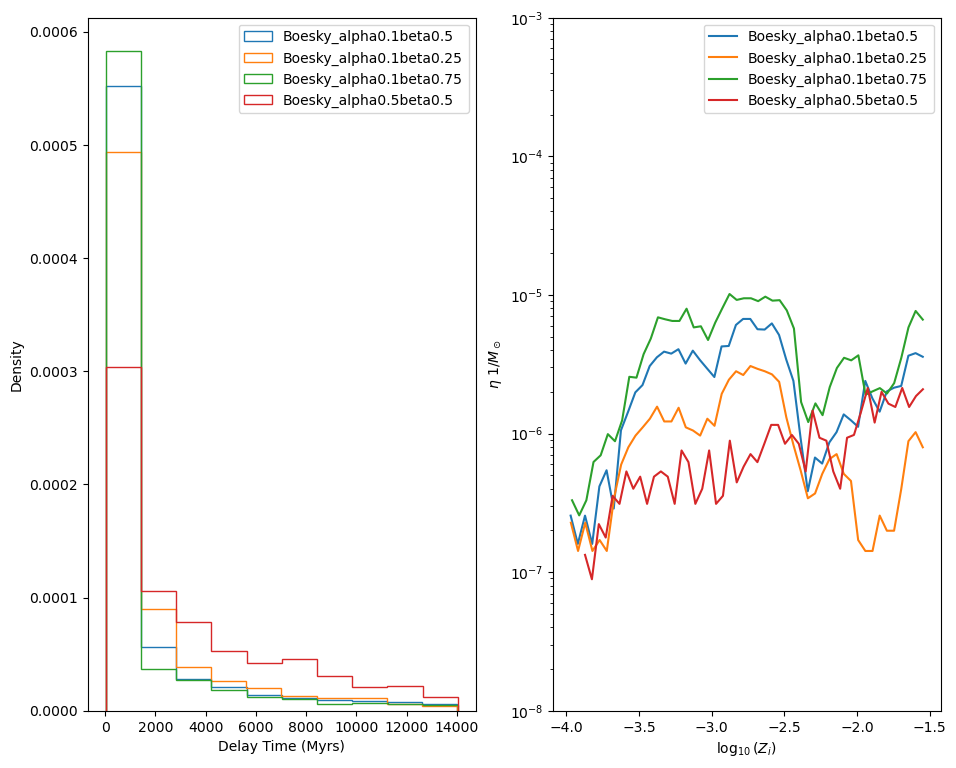

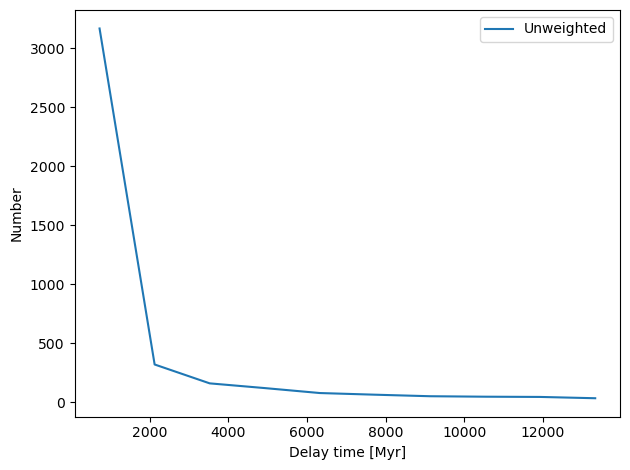

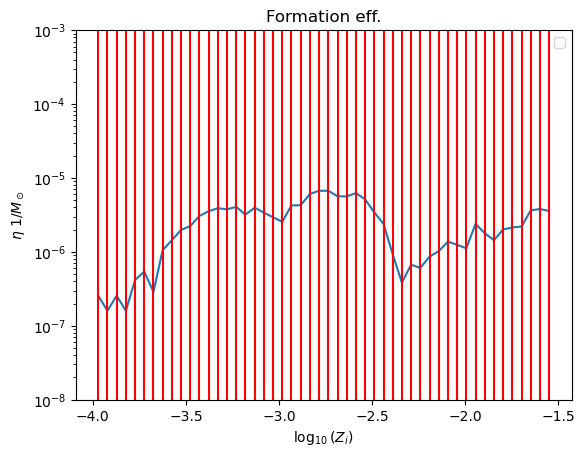

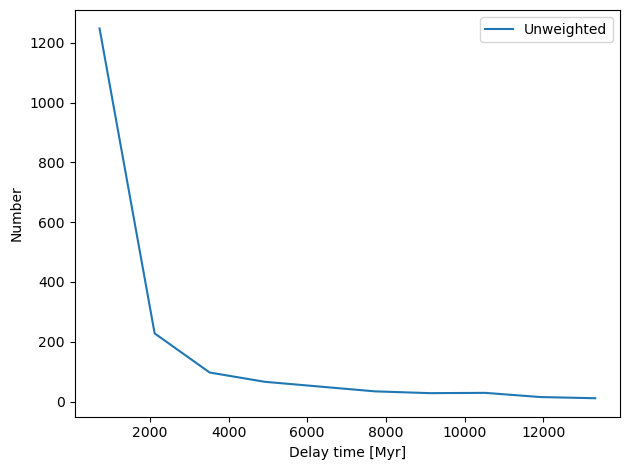

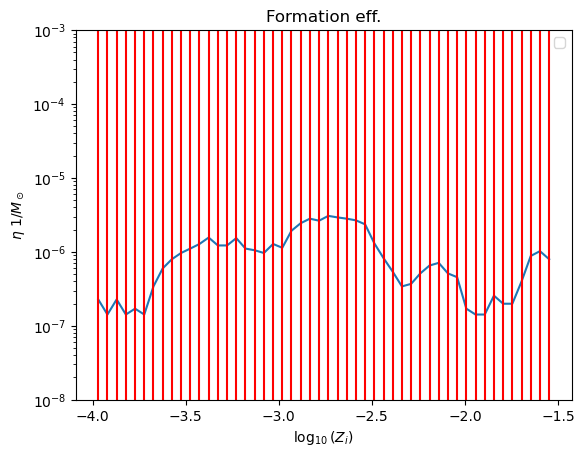

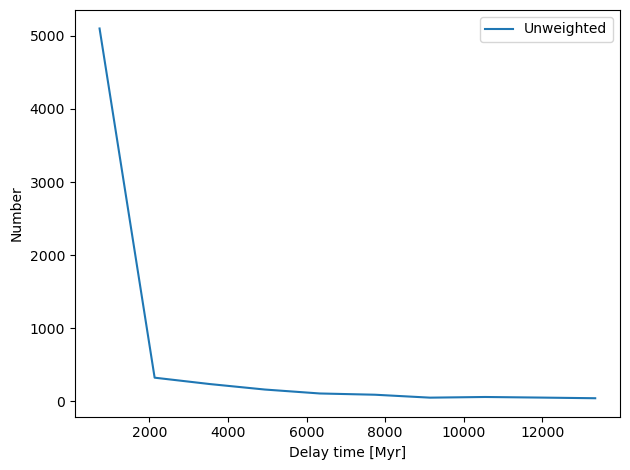

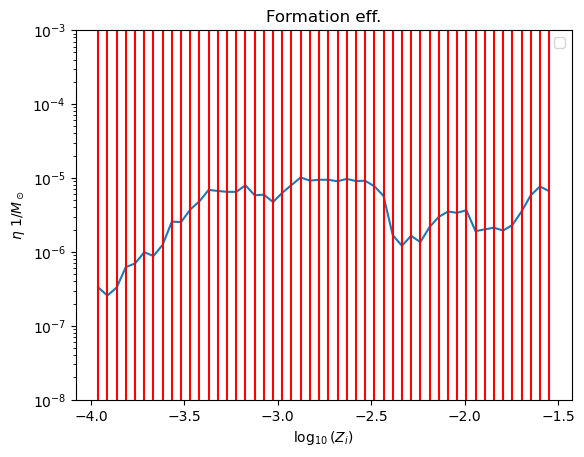

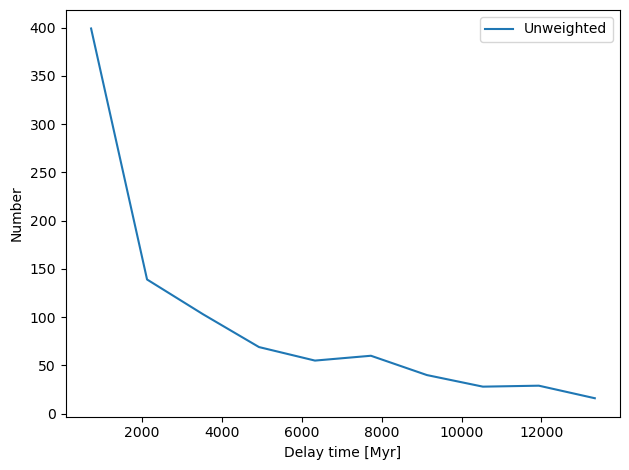

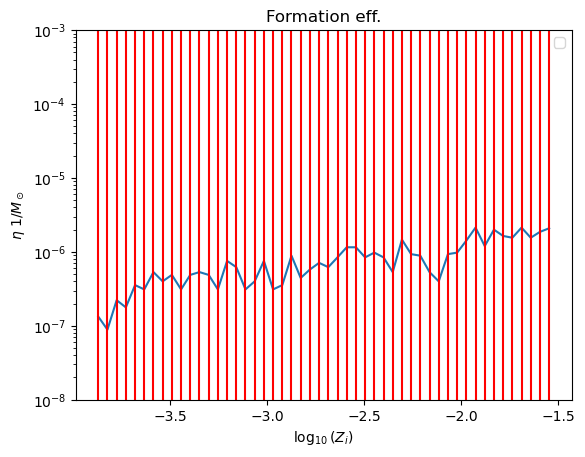

In [26]:
base = '/Volumes/Elements/'
import os
class FilePair:
    def __init__(self, name, filepath):
        self.name = name
        assert os.path.exists(filepath), filepath
        self.filepath = filepath
        
files = [
    FilePair(
        'Boesky_alpha0.1beta0.5',
        f'{base}Boesky_alpha0.1beta0.5.h5'
    ),
    FilePair(
        'Boesky_alpha0.1beta0.25',
        f'{base}Boesky_models/Alpha0.1_Beta0.25/COMPAS_Output_Weighted.h5'
    ),
    FilePair(
        'Boesky_alpha0.1beta0.75',
        f'{base}Boesky_models/Alpha0.1_Beta0.75/COMPAS_Output_Weighted.h5'
    ),
    FilePair(
        'Boesky_alpha0.5beta0.5',
        f'{base}Boesky_models/Alpha0.5_Beta0.5/COMPAS_Output_Weighted.h5'
    )
]

pop_type = 'BNS'

fig, (ax, ax2) = plt.subplots(1,2, figsize=(11,9))
for i in tqdm(range(len(files)), desc='Loading datasets'):
    f = files[i]
    dt, fe_bins, fe_data = get_info(f.filepath, pop_type)
    ax.hist(dt, label=f.name, density=True, histtype='step')
    bins_midpoints = (fe_bins[:-1] + fe_bins[1:])/2
    ax2.plot(bins_midpoints, fe_data, label=f.name)

ax.set_xlabel('Delay Time (Myrs)')
ax.set_ylabel('Density')

ax2.set_xlabel(r'$\log_{10}(Z_i)$')
ax2.set_ylabel(r'$\eta~1/{M_\odot}$') #\times d\log Z_i
ax2.set_yscale('log')
ax2.set_ylim(10e-9, 10e-4)
ax.legend()
ax2.legend()
# fig.suptitle(pop_type)
fig.show()